# Multirate simulation: a spectrum analyzer on a noisy laser

A laser with a 1 GHz Lorentzian linewidth is sampled every 20 ps (50 GHz). A **spectrum analyzer** turns it into a sliding-window spectrum: a 1024-point FFT of the most recent 1024 field samples.

A single-rate simulation would compute and store a full spectrum on *every* sample. For 2¹⁸ samples that is 2¹⁸ × 1024 complex values, or 4.3 GB. Here the analyzer only produces a spectrum every 256 samples, so the slow part of the circuit runs, and is stored, at 1/256 of the laser's rate.

The rate change is a `Decimator`, and Simphony works out on its own which components run at which rate.

This notebook shows:
1. **Rate inference.** A region's sample period follows from where it sits in the graph.
2. **Multirate sample mode.** Slow components are only evaluated, and only recorded, on their own samples.
3. **Validation.** The averaged spectrum matches the exact expected periodogram of a Lorentzian laser.
4. **The decimator's sample offset**, and what it means for timing.
5. **Compute and memory savings** compared with doing the FFT at the fast rate.
6. **The same circuit in block mode.**

## Multirate in Simphony

**Components.** `Decimator(factor=M, offset=D)` keeps samples $y[m] = u[mM + D]$. `Interpolator(factor=L, offset=D, mode="hold" | "zeros")` raises the rate, with $y[nL + D] = u[n]$. These follow the *Sample offset* convention of Simulink's Downsample and Upsample blocks.

Both resample any signal type: optical, electrical, logic or the new vector signals. They use the data fields each signal class declares in `_data_fields`. In block mode, axis 0 of every data field is time, and the simulator enforces this.

**Rate inference** (`simphony.circuit.rates`). A component's sample rate is a property of its position in the graph:
* Every source, and every component reached from a source without crossing a rate changer, runs at the reference rate `1/dt`.
* `num_time_steps` counts reference samples.
* Each rate changer multiplies the rate of its outputs by its ratio.
* If two paths into one component disagree on the net factor, that's an error.

Each region also has a phase: the time of its first sample, which a decimator's offset shifts. Every component receives a copy of the simulation parameters with *its region's* `dt`, `num_time_steps` and `time_offset`. Anything that depends on the sample period therefore sees the right value automatically. That includes laser phase-noise variance, carrier rotation, and the $z$-domain vector fits of `SParameterElement`, which also warn if their fitted band is wider than the region's sample rate.

**Sample-mode scheduling.** The circuit advances on a base tick, the gcd of all sample periods. A component in a region with period $P$ ticks and phase $p$ is only evaluated on ticks $t \equiv p \pmod P$, and holds its outputs and state in between. Each hyperperiod (the lcm of all periods) is split into runs of ticks with the same firing set. A /256 decimator gives one full tick followed by 255 fast-only ticks, each run compiled as a JAX scan with no conditionals.

Tracked ports are recorded only on their own samples. As in single-rate sample mode, each connection adds one sample of latency **at the rate of the component that produces the signal**.

**The spectrum analyzer** is the PCell `SpectrumAnalyzer`. In sample mode it expands to `SampleBuffer → Decimator → FFT`:
* The `SampleBuffer` ingests every sample. It combines all tracked carriers into one baseband field and writes it into an N-sample circular buffer, costing O(1) per sample.
* The `FFT` sits after the decimator, so it only runs on the decimated frames.

In block mode it expands to `StridedBuffer → FFT`. The `StridedBuffer` builds only the decimated windows.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize_scalar

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="Could not validate netlist")

from simphony.circuit.circuit import Circuit
from simphony.libraries.ideal.multirate import Decimator
from simphony.libraries.ideal.sources import CWLaser
from simphony.libraries.ideal.spectrum import (
    BufferedFFT,
    SpectrumAnalyzer,
    spectrum_frequencies,
    window_function,
)
from simphony.simulation.block_mode import BlockModeSimulation, BlockModeSimulationParameters
from simphony.simulation.sample_mode import SampleModeSimulation, SampleModeSimulationParameters

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#6b6b66"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2})

DT = 20e-12            # laser sample period: 50 GHz
LINEWIDTH = 1e9        # Lorentzian FWHM (Hz)
N_FFT = 1024           # 48.8 MHz resolution bins
DECIMATION = 256       # one spectrum every 5.12 ns
N_STEPS = 2**18        # 5.24 µs of laser output
WAVELENGTH = 1.55e-6

In [2]:
def analyzer_circuit(decimation=DECIMATION, offset=0, n_fft=N_FFT, fused_fft=False,
                     linewidth=LINEWIDTH):
    # Laser -> analyzer. With fused_fft=True, use BufferedFFT -> Decimator instead
    # (the FFT then runs on every fast sample).
    if fused_fft:
        netlist = {"instances": {"laser": "laser", "fft": "fft", "dec": "dec"},
                   "connections": {"laser,o0": "fft,in", "fft,out": "dec,in"},
                   "ports": {"spectrum": "dec,out"}}
        models = {"laser": CWLaser, "fft": BufferedFFT, "dec": Decimator}
        settings = {"fft": {"n_samples": n_fft, "window": "hann"},
                    "dec": {"factor": decimation, "offset": offset}}
    else:
        netlist = {"instances": {"laser": "laser", "analyzer": "analyzer"},
                   "connections": {"laser,o0": "analyzer,in"},
                   "ports": {"spectrum": "analyzer,out"}}
        models = {"laser": CWLaser, "analyzer": SpectrumAnalyzer}
        settings = {"analyzer": {"n_fft": n_fft, "decimation": decimation, "offset": offset,
                                 "window": "hann"}}
    settings["laser"] = {"wavelength": WAVELENGTH, "linewidth": linewidth}
    return Circuit(netlist, models), settings


def run_sample_mode(n_steps=N_STEPS, **kwargs):
    circuit, settings = analyzer_circuit(**kwargs)
    params = SampleModeSimulationParameters(dt=DT, num_time_steps=n_steps, mode_identifiers=("te",),
                                            optical_baseband_wavelengths=jnp.array([WAVELENGTH]))
    sim = SampleModeSimulation(circuit, settings, simulation_parameters=params)
    tic = time.time()
    result = sim.run()
    jax.block_until_ready(result.output_signals["spectrum"].value)
    return sim, result, time.time() - tic


sim, result, seconds = run_sample_mode()
spectra = np.asarray(result.output_signals["spectrum"].value[:, :, 0])

print("Inferred sample rates (period in units of dt = 20 ps):")
for (instance, domain), d in sim.rate_schedule.domains.items():
    label = f"{instance}" + (f" [{domain} ports]" if domain else "")
    print(f"  {label:32s} period {str(d.period):>4s}  dt = {d.dt*1e12:8.2f} ps  "
          f"{d.num_time_steps:7d} samples  first sample at {d.time_offset*1e12:.0f} ps")
print(f"\nhyperperiod {sim.rate_schedule.hyperperiod} ticks; simulated {N_STEPS} laser samples in {seconds:.1f} s")
print(f"spectra: {spectra.shape} (frames x bins), one every {result.sample_periods['spectrum']*1e9:.2f} ns")
single_rate_bytes = N_STEPS * N_FFT * 16
print(f"tracked spectrum memory: {spectra.nbytes/1e6:.1f} MB "
      f"(a single-rate run would store {single_rate_bytes/1e9:.1f} GB, {single_rate_bytes/spectra.nbytes:.0f}x more)")

Inferred sample rates (period in units of dt = 20 ps):
  laser                            period    1  dt =    20.00 ps   262144 samples  first sample at 0 ps
  analyzer~buffer                  period    1  dt =    20.00 ps   262144 samples  first sample at 0 ps
  analyzer~decimator [in ports]    period    1  dt =    20.00 ps   262144 samples  first sample at 0 ps
  analyzer~decimator [out ports]   period  256  dt =  5120.00 ps     1024 samples  first sample at 0 ps
  analyzer~fft                     period  256  dt =  5120.00 ps     1024 samples  first sample at 0 ps

hyperperiod 256 ticks; simulated 262144 laser samples in 4.3 s
spectra: (1024, 1024) (frames x bins), one every 5.12 ns
tracked spectrum memory: 16.8 MB (a single-rate run would store 4.3 GB, 256x more)


The PCell flattened to `analyzer~buffer`, `analyzer~decimator` and `analyzer~fft`.

The buffer runs at the laser's rate. The decimator's output port and the FFT run at 1/256 of it, so they are evaluated 1024 times rather than 262,144 times. The decimator's *input* ports belong to the fast region.

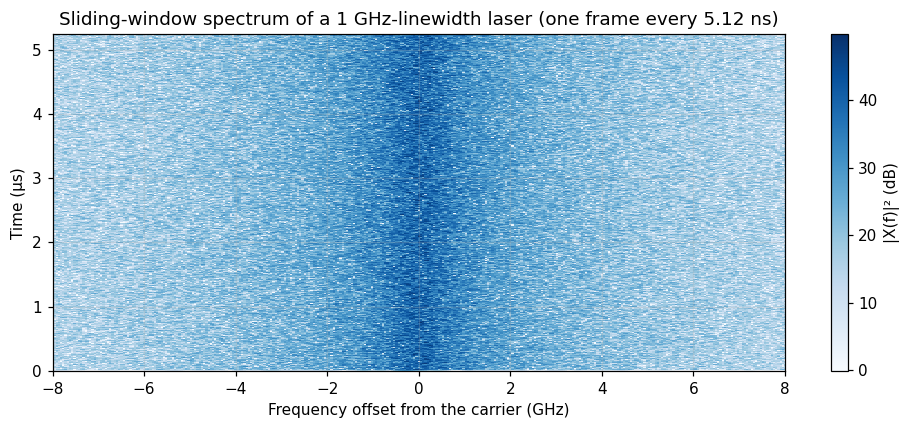

In [3]:
f_axis = np.fft.fftshift(spectrum_frequencies(N_FFT, DT))
frame_times = result.time_offsets["spectrum"] + np.arange(spectra.shape[0]) * result.sample_periods["spectrum"]
power_db = 10 * np.log10(np.fft.fftshift(np.abs(spectra) ** 2, axes=1) + 1e-12)

fig, ax = plt.subplots(figsize=(9, 4))
mesh = ax.pcolormesh(f_axis / 1e9, frame_times * 1e6, power_db, cmap="Blues", shading="auto",
                     vmin=power_db.max() - 50, vmax=power_db.max())
ax.set(xlabel="Frequency offset from the carrier (GHz)", ylabel="Time (µs)", xlim=(-8, 8),
       title="Sliding-window spectrum of a 1 GHz-linewidth laser (one frame every 5.12 ns)")
fig.colorbar(mesh, ax=ax, label="|X(f)|² (dB)")
plt.tight_layout()
plt.show()

## Validating the spectrum

For a laser with Lorentzian phase noise, the field's autocorrelation is $R(\tau) = e^{-\pi \Delta\nu |\tau|}$. The expected windowed periodogram is then exactly

$$\mathbb{E}\,|X(f)|^2 = \sum_{k=-(N-1)}^{N-1} R(k\,\Delta t)\, c_w(k)\, e^{-i 2\pi f k \Delta t}, \qquad c_w(k) = \sum_n w[n]\, w[n+k],$$

which includes the Hann window's leakage and the discrete sampling.

The averaged simulated spectra are compared with this expectation. The linewidth is also estimated by fitting $\Delta\nu$ to it.

total power: measured / expected = 0.99996
fitted linewidth: 0.998 GHz (true 1.000 GHz, from 1020 averaged frames)


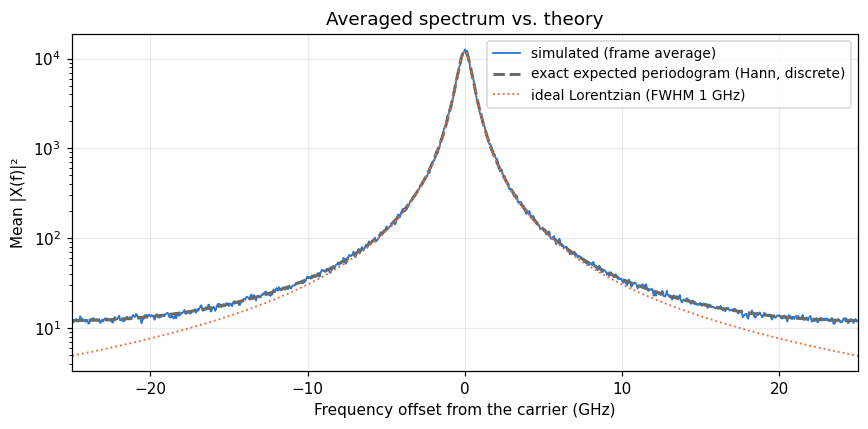

In [4]:
def expected_periodogram(linewidth, n_fft=N_FFT, dt=DT):
    w = np.asarray(window_function("hann", n_fft))
    k = np.arange(-(n_fft - 1), n_fft)
    c_w = np.correlate(w, w, mode="full")                 # sum_n w[n] w[n+k]
    R = np.exp(-np.pi * linewidth * np.abs(k) * dt)
    f = spectrum_frequencies(n_fft, dt)
    return np.real(np.exp(1j * 2 * np.pi * np.outer(f, k * dt)) @ (R * c_w))


measured = np.mean(np.abs(spectra[4:]) ** 2, axis=0)     # skip frames before the buffer fills
expected = expected_periodogram(LINEWIDTH)
fit = minimize_scalar(lambda lw: np.sum(np.log(measured / expected_periodogram(lw)) ** 2),
                      bounds=(0.2e9, 5e9), method="bounded")
print(f"total power: measured / expected = {measured.sum() / expected.sum():.5f}")
print(f"fitted linewidth: {fit.x/1e9:.3f} GHz (true {LINEWIDTH/1e9:.3f} GHz, "
      f"from {spectra.shape[0] - 4} averaged frames)")

order = np.argsort(spectrum_frequencies(N_FFT, DT))
f_sorted = spectrum_frequencies(N_FFT, DT)[order]
lorentzian = (LINEWIDTH / (2 * np.pi)) / (f_sorted**2 + (LINEWIDTH / 2) ** 2)
lorentzian *= expected[order].max() / lorentzian.max()

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(f_sorted / 1e9, measured[order], color=BLUE, lw=1.2, label="simulated (frame average)")
ax.semilogy(f_sorted / 1e9, expected[order], color=GRAY, lw=2, ls="--",
            label="exact expected periodogram (Hann, discrete)")
ax.semilogy(f_sorted / 1e9, lorentzian, color=ORANGE, lw=1.2, ls=":", label="ideal Lorentzian (FWHM 1 GHz)")
ax.set(xlabel="Frequency offset from the carrier (GHz)", ylabel="Mean |X(f)|²", xlim=(-25, 25),
       title="Averaged spectrum vs. theory")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## How closely should the spectrum follow a Lorentzian?

In the plot above the simulation agrees with the exact expected periodogram, but rises above the ideal Lorentzian toward the edges of the band. That is aliasing, not a laser error. Sampling at $f_s = 1/\Delta t$ folds the Lorentzian's slow $1/f^2$ tails back into $\pm f_s/2$. The sampled field's spectrum is the sum of the Lorentzian and all its copies shifted by $k f_s$. For phase noise this sum has a closed form, so the deviation from the ideal Lorentzian is

$$\rho(f) = \frac{S_\text{sampled}(f)}{S_\text{Lorentz}(f)} = \frac{\sinh a}{\cosh a - \cos(2\pi f/f_s)}\cdot\frac{2\pi\,\big(f^2 + (\Delta\nu/2)^2\big)}{\Delta\nu\, f_s}, \qquad a = \frac{\pi\,\Delta\nu}{f_s}.$$

A few linewidths away from the carrier ($f \gg \Delta\nu$), this simplifies to

$$\rho(f) \approx \frac{(\pi f/f_s)^2}{\sin^2(\pi f/f_s)} \approx 1 + \frac{1}{3}\left(\frac{\pi f}{f_s}\right)^2, \qquad \rho(f_s/2) = \frac{\pi^2}{4} \approx 2.47.$$

**The deviation at a given offset depends only on $f/f_s$, not on the linewidth.** The linewidth sets how far out the Lorentzian is worth looking. Viewed over $\pm K$ linewidths, the worst deviation is about $\tfrac{1}{3}(\pi K \Delta\nu/f_s)^2$, so it is the ratio $\Delta\nu/f_s$ that decides whether the ideal Lorentzian is a good description.

A second, independent requirement is resolution. The FFT bins $f_s/N$ must be much narrower than $\Delta\nu$, or the Hann window will blur the peak. We aim for at least 20 bins per linewidth.

In [5]:
def rho(f, linewidth, fs):
    # sampled (aliased) Lorentzian / ideal Lorentzian
    a = np.pi * linewidth / fs
    return (np.sinh(a) / (np.cosh(a) - np.cos(2 * np.pi * f / fs))
            * 2 * np.pi * (f**2 + (linewidth / 2) ** 2) / (linewidth * fs))


def predict(linewidth, dt, n_fft, span):
    fs = 1 / dt
    print(f"linewidth / sample rate = {linewidth * dt:.4f};  "
          f"{linewidth * n_fft * dt:.0f} FFT bins per linewidth")
    print(f"plotted span: ±{span/1e9:g} GHz = ±{span/linewidth:.0f} linewidths = ±{span/fs:.3f} f_s")
    print(f"expected deviation at the span edge: x{rho(span, linewidth, fs):.4f} "
          f"(estimate 1 + (pi f/f_s)^2/3 = x{1 + (np.pi * span / fs) ** 2 / 3:.4f})")


def lorentzian_check(measured, linewidth, dt, n_fft, span, title):
    # measured: frame-averaged |X(f)|^2 (FFT order). Compares it with the ideal and the
    # sampled Lorentzian, both in periodogram units: E|X|^2 = sum(w^2) * S(f) / dt.
    f = spectrum_frequencies(n_fft, dt)
    order = np.argsort(f)
    f, measured = f[order], measured[order]
    scale = np.sum(np.asarray(window_function("hann", n_fft)) ** 2) / dt
    ideal = scale * (linewidth / (2 * np.pi)) / (f**2 + (linewidth / 2) ** 2)
    sampled = ideal * rho(f, linewidth, 1 / dt)
    inside = np.abs(f) <= span

    fig, (top, bottom) = plt.subplots(2, 1, figsize=(8, 5.6), sharex=True,
                                      gridspec_kw={"height_ratios": [2, 1]})
    top.semilogy(f[inside] / 1e9, measured[inside], color=BLUE, lw=1.2, label="simulated (frame average)")
    top.semilogy(f[inside] / 1e9, ideal[inside], color=ORANGE, lw=1.5, ls=":", label="ideal Lorentzian")
    top.semilogy(f[inside] / 1e9, sampled[inside], color=GRAY, lw=1.5, ls="--", label="sampled Lorentzian, ρ(f)")
    top.set(ylabel="Mean |X(f)|²", title=title)
    top.legend(loc="lower center", fontsize=9)
    bottom.plot(f[inside] / 1e9, measured[inside] / ideal[inside], color=BLUE, lw=0.8, alpha=0.7,
                label="simulated / ideal")
    bottom.plot(f[inside] / 1e9, rho(f[inside], linewidth, 1 / dt), color=GRAY, lw=2, ls="--",
                label="predicted ρ(f)")
    bottom.axhline(1, color=ORANGE, lw=1, ls=":")
    bottom.set(xlabel="Frequency offset from the carrier (GHz)", ylabel="ratio to ideal",
               xlim=(-span / 1e9, span / 1e9))
    bottom.legend(loc="upper center", fontsize=9, ncol=2)
    plt.tight_layout()
    plt.show()

    edge = inside & (np.abs(f) >= 0.8 * span)
    print(f"outer 20% of the span: simulated/ideal = {np.mean(measured[edge] / ideal[edge]):.3f}, "
          f"predicted {np.mean(rho(f[edge], linewidth, 1 / dt)):.3f}")

### Case 1: linewidth much smaller than the sample rate

**Setup:** Δν = 100 MHz sampled at 50 GHz, so Δν/f_s = 0.002. The view is ±10 linewidths (±1 GHz), which is only 0.02 f_s. A 16384-point FFT gives 3 MHz bins, about 33 per linewidth.

**Expected deviation:** aliasing should add only about $\tfrac13(\pi\cdot 0.02)^2 \approx 0.13\%$ at the edge. That is far below the statistical scatter of the averaged periodogram, so the simulation should sit on the ideal Lorentzian.

linewidth / sample rate = 0.0020;  33 FFT bins per linewidth
plotted span: ±1 GHz = ±10 linewidths = ±0.020 f_s
expected deviation at the span edge: x1.0013 (estimate 1 + (pi f/f_s)^2/3 = x1.0013)


508 frames averaged (34.3 s)


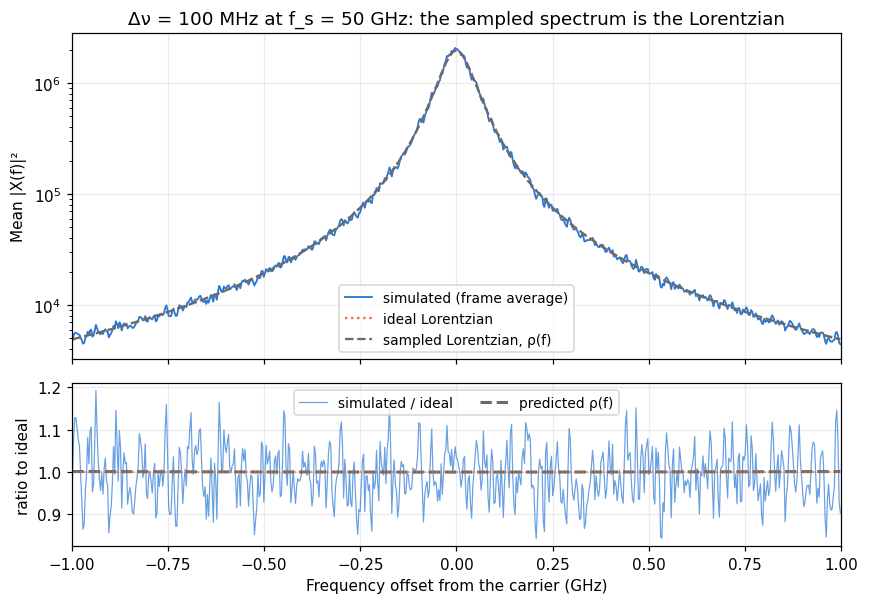

outer 20% of the span: simulated/ideal = 0.999, predicted 1.001


In [6]:
LW_NARROW, N_FFT_NARROW, SPAN_NARROW = 100e6, 16384, 1e9
predict(LW_NARROW, DT, N_FFT_NARROW, SPAN_NARROW)

_, narrow, seconds = run_sample_mode(2**21, linewidth=LW_NARROW, n_fft=N_FFT_NARROW, decimation=4096)
narrow_spectra = np.asarray(narrow.output_signals["spectrum"].value[:, :, 0])
narrow_measured = np.mean(np.abs(narrow_spectra[4:]) ** 2, axis=0)
print(f"{narrow_spectra.shape[0] - 4} frames averaged ({seconds:.1f} s)")
lorentzian_check(narrow_measured, LW_NARROW, DT, N_FFT_NARROW, SPAN_NARROW,
                 "Δν = 100 MHz at f_s = 50 GHz: the sampled spectrum is the Lorentzian")

### Case 2: tails that reach the Nyquist frequency

**Setup:** this is the run above, Δν = 1 GHz at 50 GHz (Δν/f_s = 0.02). It is viewed out to the Nyquist frequency, ±25 GHz, which is ±25 linewidths.

**Expected deviation:** the exact ρ is ×1.14 at 10 GHz, ×1.75 at 20 GHz and π²/4 ≈ ×2.47 at the band edge. The small-angle estimate 1 + (πf/f_s)²/3 (×1.53 at 20 GHz) understates it this close to Nyquist. Within a few linewidths of the carrier, the deviation is still under 1%.

Sampling faster brings the ideal Lorentzian back. For example, 500 GHz would give ×1.008 at 25 GHz.

linewidth / sample rate = 0.0200;  20 FFT bins per linewidth
plotted span: ±25 GHz = ±25 linewidths = ±0.500 f_s
expected deviation at the span edge: x2.4676 (estimate 1 + (pi f/f_s)^2/3 = x1.8225)


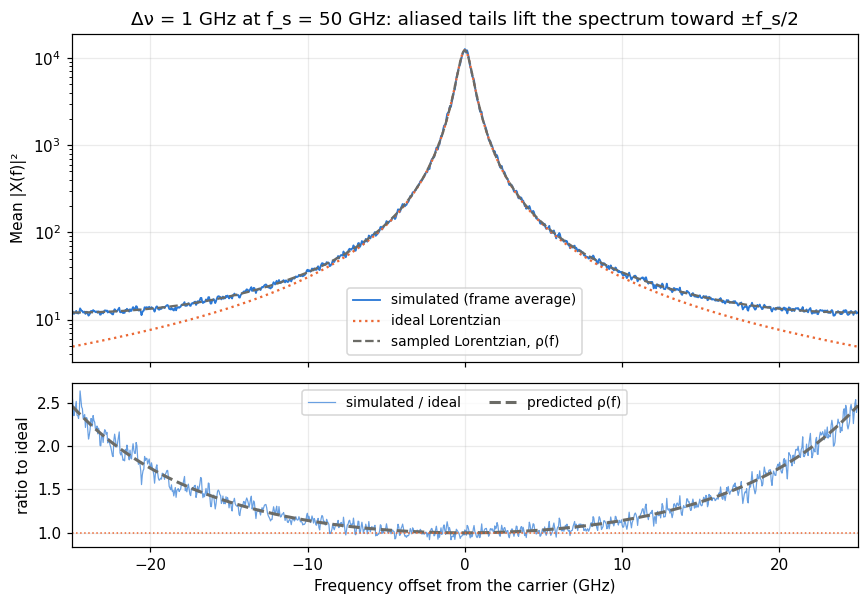

outer 20% of the span: simulated/ideal = 2.075, predicted 2.068


In [7]:
predict(LINEWIDTH, DT, N_FFT, 25e9)
lorentzian_check(measured, LINEWIDTH, DT, N_FFT, 25e9,
                 "Δν = 1 GHz at f_s = 50 GHz: aliased tails lift the spectrum toward ±f_s/2")

## The decimator's sample offset

`offset` (Simulink's *Sample offset*) picks which of the $M$ phases the decimator keeps. With /256 and `offset=128`, every frame is taken 128 samples (2.56 ns) later than with `offset=0`.

The laser's noise sequence doesn't depend on the rate schedule. So the frames of two /256 analyzers, one at offset 0 and one at offset 128, interleave into exactly the frames of a /128 analyzer.

Frame k at offset 0 equals /128 frame 2k−1, and frame k at offset 128 equals /128 frame 2k. The odd/even assignment comes from the FFT's one-slow-sample connection latency, which spans two /128 samples at /256.

offset 0   frames == /128 frames 2k-1: True
offset 128 frames == /128 frames 2k  : True
first-sample times (ns): {'offset 0': 0.0, 'offset 128': 2.56, '/128': 0.0}


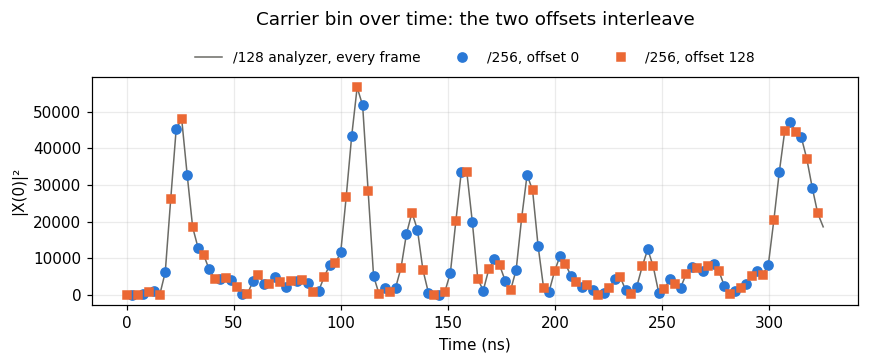

In [8]:
n_short = 2**14
_, r0, _ = run_sample_mode(n_short, decimation=256, offset=0)
_, r128, _ = run_sample_mode(n_short, decimation=256, offset=128)
_, r_half, _ = run_sample_mode(n_short, decimation=128, offset=0)
a = np.asarray(r0.output_signals["spectrum"].value[:, :, 0])
b = np.asarray(r128.output_signals["spectrum"].value[:, :, 0])
c = np.asarray(r_half.output_signals["spectrum"].value[:, :, 0])
print("offset 0   frames == /128 frames 2k-1:", np.allclose(a[1:], c[1::2][: len(a) - 1]))
print("offset 128 frames == /128 frames 2k  :", np.allclose(b, c[0::2]))
print("first-sample times (ns):", {k: round(r.time_offsets['spectrum'] * 1e9, 3)
                                   for k, r in (("offset 0", r0), ("offset 128", r128), ("/128", r_half))})

peak = np.argmin(np.abs(spectrum_frequencies(N_FFT, DT)))
t_half = (r_half.time_offsets["spectrum"] + np.arange(len(c)) * r_half.sample_periods["spectrum"]) * 1e9
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(t_half, np.abs(c[:, peak]) ** 2, color=GRAY, lw=1, label="/128 analyzer, every frame")
ax.plot(t_half[1::2][: len(a) - 1], np.abs(a[1:, peak]) ** 2, "o", color=BLUE, ms=6, label="/256, offset 0")
ax.plot(t_half[0::2], np.abs(b[:, peak]) ** 2, "s", color=ORANGE, ms=5, label="/256, offset 128")
ax.set(xlabel="Time (ns)", ylabel="|X(0)|²")
ax.set_title("Carrier bin over time: the two offsets interleave", pad=34)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, fontsize=9, frameon=False)
plt.tight_layout()
plt.show()

## Compute: running the FFT at the slow rate

The same spectra can be produced by `BufferedFFT → Decimator`, which computes the FFT on every laser sample and throws away 255 of every 256.

The per-sample cost is measured as the slope between runs of 2¹⁶ and 2¹⁸ samples, which removes the compilation time.

In [9]:
rows = []
for n_fft in (1024, 4096):
    for fused in (False, True):
        t = {n: run_sample_mode(n, n_fft=n_fft, fused_fft=fused)[2] for n in (2**16, 2**18)}
        per_sample = (t[2**18] - t[2**16]) / (2**18 - 2**16)
        rows.append((n_fft, "BufferedFFT → Decimator" if fused else "SampleBuffer → Decimator → FFT", per_sample))
for n_fft, layout, per_sample in rows:
    print(f"N_FFT = {n_fft}:  {layout:32s} {per_sample*1e6:6.2f} µs per laser sample")
for n_fft in (1024, 4096):
    slow, fast = [r[2] for r in rows if r[0] == n_fft]
    print(f"N_FFT = {n_fft}: FFT at the slow rate is {fast/slow:.1f}x faster")

N_FFT = 1024:  SampleBuffer → Decimator → FFT     3.89 µs per laser sample
N_FFT = 1024:  BufferedFFT → Decimator            7.73 µs per laser sample
N_FFT = 4096:  SampleBuffer → Decimator → FFT     5.97 µs per laser sample
N_FFT = 4096:  BufferedFFT → Decimator           21.67 µs per laser sample
N_FFT = 1024: FFT at the slow rate is 2.0x faster
N_FFT = 4096: FFT at the slow rate is 3.6x faster


Moving the FFT behind the decimator cuts the work per laser sample by 2× at N = 1024 and about 4× at N = 4096; the saving grows with the FFT size. At this point the remaining cost per fast sample is the laser and the buffer write, not the FFT.

The memory saving, 256× here, holds for both layouts, because tracked ports are stored at their own rate.

## The same analyzer in block mode

In block mode the analyzer PCell expands to `StridedBuffer → FFT`. The strided buffer is itself a rate changer that only builds every 256th window, so the full (2¹⁸ × 1024) block of windows is never formed. The laser uses `CWLaser`'s block-mode phase noise, which is a different noise realization, so only statistics are compared.

In [10]:
circuit, settings = analyzer_circuit()
params = BlockModeSimulationParameters(dt=DT, num_time_steps=N_STEPS, mode_identifiers=("te",),
                                       optical_baseband_wavelengths=jnp.array([WAVELENGTH]))
tic = time.time()
block_result = BlockModeSimulation(circuit, settings, simulation_parameters=params).run()
block_spectra = np.asarray(block_result.output_signals["spectrum"].value[:, :, 0])
print(f"block mode: {block_spectra.shape} spectra in {time.time() - tic:.1f} s, "
      f"one every {block_result.sample_periods['spectrum']*1e9:.2f} ns")
block_measured = np.mean(np.abs(block_spectra[4:]) ** 2, axis=0)
block_fit = minimize_scalar(lambda lw: np.sum(np.log(block_measured / expected_periodogram(lw)) ** 2),
                            bounds=(0.2e9, 5e9), method="bounded")
print(f"block-mode fitted linewidth: {block_fit.x/1e9:.3f} GHz (true {LINEWIDTH/1e9:.3f} GHz)")

block mode: (1024, 1024) spectra in 1.1 s, one every 5.12 ns


block-mode fitted linewidth: 1.000 GHz (true 1.000 GHz)


## Summary

* **Rates come from the graph.** Sources run at `dt`. Decimators and interpolators change the rate of everything downstream, and each component receives its own region's `dt`, `num_time_steps` and `time_offset`.
* **Sample mode evaluates and stores slow components at their own rate.** Here that was 1024 FFT evaluations and 16.8 MB, where a single-rate run would need 262,144 FFTs and 4.3 GB. The noise statistics are unchanged: the fitted linewidth recovers the 1 GHz input.
* **The sample offset works like Simulink's**, and the latency rule (one sample per connection, at the producing rate) makes frame timing predictable.
* **Block mode** supports the same rate changers, and the analyzer PCell picks a block-mode design that never builds the full window array.

**Next steps:** filtering decimators and interpolators (polyphase FIR); slow electrical control loops, such as heater locking, driving fast optics through an `Interpolator`; and fractional rate changes (L/M).